# Imports & GPU Setup

In [14]:
import io
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from tensorflow.keras import layers, models, regularizers

# GPU memory growth setup
physical_devices = tf.config.list_physical_devices("GPU")
for dev in physical_devices:
    try:
        tf.config.experimental.set_memory_growth(dev, True)
    except RuntimeError:
        pass

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Configuration

In [15]:
HDF5_PATH  = '../output_train'
BATCH_SIZE = 16  
EPOCHS     = 20

# Data Loading Logic

In [16]:
from pathlib import Path

import h5py
import numpy as np
import tensorflow as tf
from tqdm.auto import tqdm


class HydroH5FolderLoader:
    """Streams images and labels from a directory or list of HDF5 files."""

    def __init__(self, h5_source, img_key=None, y_key=None):
        self.files = self._resolve_files(h5_source)
        (
            self.img_key,
            self.y_key,
            self.img_shape,
            self.img_dtype,
            self.length,
            self.file_counts,
        ) = self._inspect_files(img_key, y_key)
        self.file_offsets = np.concatenate(([0], np.cumsum(self.file_counts, dtype=np.int64)))

    @staticmethod
    def _resolve_files(h5_source):
        if isinstance(h5_source, (str, Path)):
            h5_source = Path(h5_source)
            if h5_source.is_dir():
                files = sorted(h5_source.rglob("*.h5")) + sorted(h5_source.rglob("*.hdf5"))
            elif h5_source.is_file():
                files = [h5_source]
            else:
                raise FileNotFoundError(f"No such file or directory: {h5_source}")
        else:
            files = [Path(p) for p in h5_source]

        if not files:
            raise FileNotFoundError("No HDF5 files found.")
        return files

    @staticmethod
    def _pick_key(f, requested_key, candidates):
        if requested_key is not None:
            if requested_key not in f:
                raise KeyError(f"Key '{requested_key}' not found in {f.filename}")
            return requested_key

        for key in candidates:
            if key in f:
                return key

        raise KeyError(f"Could not infer dataset key in {f.filename}. Available keys: {list(f.keys())}")

    def _inspect_files(self, img_key, y_key):
        with h5py.File(self.files[0], "r") as f:
            img_key = self._pick_key(f, img_key, ("image", "images", "rgb", "color", "colors"))
            y_key = self._pick_key(f, y_key, ("ride_height", "label", "labels", "target", "y"))

            img_ds = f[img_key]
            if img_ds.ndim == 3:
                img_shape = tuple(img_ds.shape)
                first_count = 1
            elif img_ds.ndim == 4:
                img_shape = tuple(img_ds.shape[1:])
                first_count = int(img_ds.shape[0])
            else:
                raise ValueError(f"Unsupported image shape in {self.files[0]}: {img_ds.shape}")

            img_dtype = np.dtype(img_ds.dtype)

            y_ds = f[y_key]
            y_count = int(np.prod(y_ds.shape)) if y_ds.shape else 1
            if y_count != first_count:
                raise ValueError(f"Mismatched image/label count in {self.files[0]}")

        total = 0
        file_counts = []

        for path in tqdm(self.files, desc="Indexing HDF5 files"):
            with h5py.File(path, "r") as f:
                img_ds = f[img_key]
                y_ds = f[y_key]

                if img_ds.ndim == 3:
                    count = 1
                    current_shape = tuple(img_ds.shape)
                elif img_ds.ndim == 4:
                    count = int(img_ds.shape[0])
                    current_shape = tuple(img_ds.shape[1:])
                else:
                    raise ValueError(f"Unsupported image shape in {path}: {img_ds.shape}")

                if current_shape != img_shape:
                    raise ValueError(f"Inconsistent image shape in {path}: {current_shape} != {img_shape}")

                y_count = int(np.prod(y_ds.shape)) if y_ds.shape else 1
                if y_count != count:
                    raise ValueError(f"Mismatched image/label count in {path}")

                total += count
                file_counts.append(count)

        return img_key, y_key, img_shape, img_dtype, total, file_counts

    def _iter_samples(self, indices, *, shuffle=False, repeat=False, seed=42):
        rng = np.random.default_rng(seed)
        base_indices = np.asarray(indices, dtype=np.int64)

        while True:
            epoch_indices = rng.permutation(base_indices) if shuffle else np.sort(base_indices)
            file_ids = np.searchsorted(self.file_offsets[1:], epoch_indices, side="right")

            file_to_local = {}
            for global_idx, file_id in zip(epoch_indices, file_ids):
                local_idx = int(global_idx - self.file_offsets[file_id])
                file_to_local.setdefault(int(file_id), []).append(local_idx)

            ordered_file_ids = list(file_to_local.keys())
            if shuffle and len(ordered_file_ids) > 1:
                rng.shuffle(ordered_file_ids)

            for file_id in ordered_file_ids:
                local_indices = file_to_local[file_id]
                if shuffle and len(local_indices) > 1:
                    rng.shuffle(local_indices)

                with h5py.File(self.files[file_id], "r") as f:
                    img_ds = f[self.img_key]
                    y_ds = f[self.y_key]

                    if img_ds.ndim == 3:
                        image = np.asarray(img_ds[()])
                        label = np.asarray(y_ds[()], dtype=np.float32).reshape(-1)[0]
                        yield image, np.array([label], dtype=np.float32)
                    else:
                        for local_idx in local_indices:
                            image = np.asarray(img_ds[local_idx])
                            label = np.asarray(y_ds[local_idx], dtype=np.float32).reshape(-1)[0]
                            yield image, np.array([label], dtype=np.float32)

            if not repeat:
                break

def get_split_datasets(loader: HydroH5FolderLoader, batch_size: int = BATCH_SIZE, split_ratio: float = 0.8):
    # 1. Shuffle the file paths themselves (Zero RAM cost)
    all_files = np.array([str(f) for f in loader.files])
    rng = np.random.default_rng(seed=42)
    indices = rng.permutation(len(all_files))
    
    split_at = int(len(all_files) * split_ratio)
    train_files = all_files[indices[:split_at]]
    val_files = all_files[indices[split_at:]]

    def load_h5_file(file_path):
        def _read_data(path):
            with h5py.File(path.numpy().decode('utf-8'), "r") as f:
                img = np.array(f[loader.img_key], dtype=np.uint8)
                # 1. CHANGE: Ensure labels are always 2D (N, 1)
                # Even for a single sample, this makes it (1, 1)
                lbl = np.array(f[loader.y_key], dtype=np.float32).reshape(-1, 1)
                
                if img.ndim == 3: 
                    img = img[np.newaxis, ...]
            return img, lbl

        res = tf.py_function(_read_data, [file_path], [tf.uint8, tf.float32])
        
        # 2. MATCH: Ensure set_shape matches the 2D rank from _read_data
        res[0].set_shape([None, *loader.img_shape]) # (Samples, H, W, C)
        res[1].set_shape([None, 1])                 # (Samples, 1)
        
        return tf.data.Dataset.from_tensor_slices(tuple(res))

    def make_ds(files, is_training=True):
        ds = tf.data.Dataset.from_tensor_slices(files)
        if is_training:
            ds = ds.shuffle(len(files))
        
        # Parallel read, but keep cycle_length modest (e.g., 4 or 8)
        ds = ds.interleave(
            load_h5_file,
            cycle_length=4, 
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=False
        )
        
        # We no longer need a massive shuffle buffer here because files were shuffled
        if is_training:
            ds = ds.shuffle(batch_size * 2) 
            
        ds = ds.batch(batch_size, drop_remainder=True)
        
        # IMPORTANT: Remove the .map(lambda x, y: tf.cast...) line
        # The model's Rescaling layer handles this on the GPU!
        
        return ds.prefetch(512) # Buffer only 64 batches to save RAM

    train_ds = make_ds(train_files, is_training=True).repeat()
    val_ds = make_ds(val_files, is_training=False)

    train_steps = len(train_files) // batch_size
    val_steps = len(val_files) // batch_size

    return train_ds, val_ds, loader.img_shape, train_steps, val_steps

loader = HydroH5FolderLoader(HDF5_PATH)
print(f"\nIndexed {loader.length} samples from {len(loader.files)} HDF5 files")
print(f"Image shape: {loader.img_shape}, dtype: {loader.img_dtype}")

images = None
labels = None

train_ds, val_ds, img_shape, train_steps, val_steps = get_split_datasets(loader)

Indexing HDF5 files: 100%|██████████| 3200/3200 [00:01<00:00, 2761.10it/s]


Indexed 3200 samples from 3200 HDF5 files
Image shape: (720, 960, 3), dtype: uint8


# Model Architecture

In [17]:
def residual_block(x, filters, downsample=False, reg=None):
    stride = 2 if downsample else 1
    y = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, kernel_regularizer=reg)(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.Conv2D(filters, 3, strides=1, padding="same", use_bias=False, kernel_regularizer=reg)(y)
    y = layers.BatchNormalization()(y)

    if downsample or x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(layers.Add()([x, y]))

def build_model(input_shape):
    reg = regularizers.l2(1e-4)
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs) # Normalize pixel values to [0, 1]
    x = layers.Conv2D(32, 7, strides=2, padding="same", use_bias=False, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # Stages
    for f in [32, 64, 128, 256]:
        x = residual_block(x, f, downsample=(f!=32), reg=reg)
        x = residual_block(x, f, reg=reg)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="linear", dtype='float32')(x)

    model = models.Model(inputs, outputs)
    
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3, decay_steps=(EPOCHS * train_steps), alpha=1e-6
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss=tf.keras.losses.Huber(delta=0.1),
        metrics=["mae"]
    )
    return model

model = build_model(img_shape)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 720, 960,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 720, 960,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 360, 480,  │      4,704 │ rescaling_2[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 480,  │        128 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 360, 480,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 180, 240,  │          0 │ activation_34[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 180, 240,  │      9,216 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 240,  │        128 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 180, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 180, 240,  │      9,216 │ activation_35[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 240,  │        128 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 180, 240,  │          0 │ max_pooling2d_2[… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 180, 240,  │          0 │ add_16[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 180, 240,  │      9,216 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 240,  │        128 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 180, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 180, 240,  │      9,216 │ activation_37[0]

 Total params: 2,836,705 (10.82 MB)

 Trainable params: 2,831,905 (10.80 MB)

 Non-trainable params: 4,800 (18.75 KB)

# Training

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=5, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20


I0000 00:00:1773693420.216561  253007 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71545__.188
E0000 00:00:1773693421.283546  253007 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


160/160 ━━━━━━━━━━━━━━━━━━━━ 84s 323ms/step - loss: 0.1971 - mae: 0.1862 - val_loss: 0.1616 - val_mae: 0.3591
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 58s 366ms/step - loss: 0.1023 - mae: 0.1097 - val_loss: 0.1109 - val_mae: 0.4755
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 59s 369ms/step - loss: 0.0588 - mae: 0.1001 - val_loss: 0.0664 - val_mae: 0.3010
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 59s 373ms/step - loss: 0.0391 - mae: 0.0966 - val_loss: 0.0641 - val_mae: 0.4186
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 59s 370ms/step - loss: 0.0286 - mae: 0.0912 - val_loss: 0.0271 - val_mae: 0.1168
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 57s 359ms/step - loss: 0.0219 - mae: 0.0839 - val_loss: 0.0412 - val_mae: 0.3090
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 61s 384ms/step - loss: 0.0173 - mae: 0.0767 - val_loss: 0.0235 - val_mae: 0.1615
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 71s 447ms/step - loss: 0.0143 - mae: 0.0713 - val_loss: 0.0120 - val_mae: 0.0538
Epoch 9/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 69s

# Visualizing Results

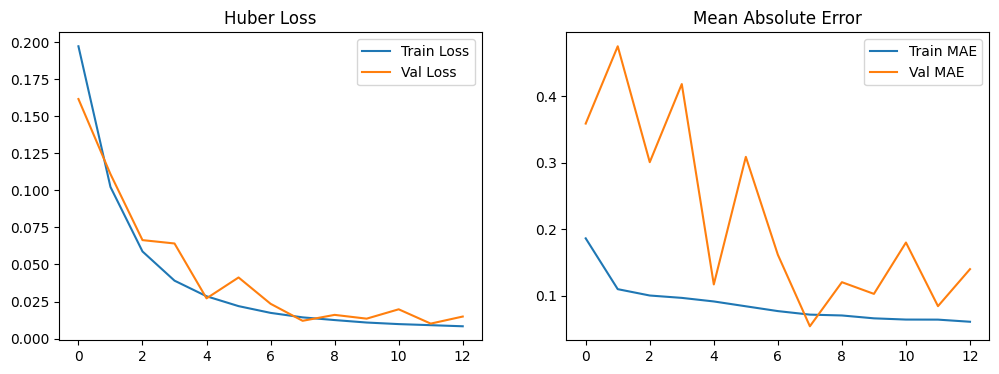

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Huber Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.legend()

plt.show()

In [ ]:
# TensorFlow/Keras inference on validation dataset
y_true, y_pred = [], []

for x, y in val_ds.take(val_steps):
    pred = model(x, training=False).numpy().flatten()
    y_true.extend(y.numpy().flatten())
    y_pred.extend(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true)**2))
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10)
mn, mx = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx])  # y=x reference
plt.xlabel("True ride_height")
plt.ylabel("Predicted ride_height")
plt.title("ResNet-18 Regression: Predicted vs True")
plt.grid(True)
plt.show()